# Vertical integration

Vertical integration combines modalities measured in the same cells. Examples are RNA and surface protein from CITE-seq, or RNA and ATAC from 10x Multiome. This tutorial uses `D11`, a CITE-seq dataset of 2,864 cells.

## 1. Install

The first cell installs `multibench-sc`. Methods run only on Linux, each in its own environment. Set `INSTALL_ENVS = True` on Linux or Colab to download the environments. On macOS and Windows every cell still runs and uses stored outputs instead.

<details>
<summary>Details</summary>

With `INSTALL_ENVS = False`, the notebook downloads only the reference data and the stored outputs. A method cell then prints one line and loads those outputs.

With `INSTALL_ENVS = True`, the cells download prebuilt environments and run the methods, with no conda needed.

On Colab, choose a GPU runtime first: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, training methods are much slower.

</details>

In [1]:
import importlib.metadata, importlib.util, sys
if importlib.util.find_spec("multibench") is None:
    # keep the numpy / pandas this interpreter already has
    pins = [f"{p}=={importlib.metadata.version(p)}" for p in ("numpy", "pandas") if importlib.util.find_spec(p)]
    !{sys.executable} -m pip -q install "multibench-sc>=0.3.2" {" ".join(pins)}
    importlib.invalidate_caches()
    # not on PyPI yet: install from GitHub
    if importlib.util.find_spec("multibench") is None:
        !{sys.executable} -m pip -q install "git+https://github.com/DSichang/scMultiBench.git" {" ".join(pins)}
else:
    print("multibench already installed")

multibench already installed


In [2]:
# False: no environment is downloaded; method cells use stored outputs.
# True (Linux or Colab): run the methods here; no conda needed.
# 3 envs, 1.5 GB to download on a CPU host, 6.2 GB on a GPU host.
INSTALL_ENVS = False

In [3]:
%matplotlib inline
import warnings
from pathlib import Path
import anndata
import pandas as pd
from tqdm import TqdmWarning
# hide library warnings; the warnings of multibench stay visible
for _w in (FutureWarning, DeprecationWarning, pd.errors.PerformanceWarning,
           anndata.ImplicitModificationWarning, TqdmWarning):
    warnings.filterwarnings("ignore", category=_w)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
import multibench as mtb

DATASET  = "D11"
CATEGORY = "vertical"
# the reference data (11 MB), downloaded once
mtb.data.fetch('D11')
print("multibench", mtb.__version__)

multibench 0.3.2


## 2. Run the analysis

### Environments: only if you will run methods

The next cell installs the environments for Matilda, sciPENN and scMM: 3 envs, 1.5 GB to download on a CPU host, 6.2 GB on a GPU host. It downloads nothing unless `INSTALL_ENVS = True` and the computer runs Linux.

<details>
<summary>Details</summary>

Environments are unpacked under `mtb.config.DEFAULT.envs_dir`. Set it before this cell to use another disk. Without conda on the computer, the default is `~/.cache/multibench/envs`. An environment that is already there is not downloaded again.

To install every vertical environment from a terminal, run `multibench env install --category vertical --packed --run`. That is 18 envs, 48.1 GB to download on a CPU host, 56.4 GB on a GPU host. `multibench env plan --category vertical` lists the size of each.

</details>

In [4]:
import sys
if not INSTALL_ENVS:
    print("INSTALL_ENVS is False: no environment is downloaded")
elif sys.platform != "linux":
    print("method environments run only on Linux: skipped on", sys.platform)
else:
    # dry run: sizes only
    plan = mtb.env.install(['Matilda', 'sciPENN', 'scMM'], category=CATEGORY)
    todo = [r for r in plan if not r["exists"]]
    print(f"{len(todo)} of {len(plan)} envs to download, {sum(r['archive_bytes'] or 0 for r in todo) / 1e9:.1f} GB")
    for r in mtb.env.install(['Matilda', 'sciPENN', 'scMM'], category=CATEGORY, packed=True, dry_run=False):
        print(f"{r['env']:20s} {r['state']}")

INSTALL_ENVS is False: no environment is downloaded


### Run the methods

`run_all` runs Matilda, sciPENN and scMM on `D11`, each in its own environment. Each method writes an embedding. An embedding is a table of numbers with one row per cell. `run_all` scores each embedding with the scIB metrics. Without environments, the cell prints one line and loads stored outputs instead.

<details>
<summary>Details</summary>

The stored outputs are the `run_all` outputs for `D11` from the benchmark's Linux machine. `mtb.data.fetch_outputs` downloads them and `mtb.load_batch` reloads them, so the embeddings and run times are real.

If that download fails, the cell uses the stored metric table (`load_results(source="rerun")`) instead. The `status` column then reads `STORED`, and there is no embedding to score.

`params={"Matilda": {"epochs": 5}}` runs Matilda with epochs 5 instead of its default 30, so the demo run is short.

</details>

In [5]:
def stored_sweep(dataset, methods=None):
    """The stored results for `dataset`, as the object `run_all` returns."""
    long = mtb.load_results(CATEGORY, dataset=dataset, source="rerun", methods=methods)
    recs = [{"method": m, "status": "STORED", "metrics": g.set_index("metric")["value"].to_dict()}
            for m, g in long.groupby("method")]
    return mtb.BatchResult(recs, dataset, CATEGORY)

def replacement(dataset, methods, stored):
    """The run_all outputs for `dataset` from the benchmark's Linux machine; the stored results if that download fails."""
    try:
        res = mtb.load_batch(mtb.data.fetch_outputs(dataset), methods=methods)
        print(f"replacement: the run_all outputs for {dataset} from the benchmark's Linux machine, with embeddings and run times")
        return res
    # offline, or the outputs are not published yet
    except Exception as e:
        print(f"replacement: the package's stored metric table. {type(e).__name__} from fetch_outputs: {e}")
        return stored_sweep(*stored)

check = mtb.scan("D11", CATEGORY, methods=['Matilda', 'sciPENN', 'scMM'])
if check.env_ok.any():
    res = mtb.run_all("D11", CATEGORY,
                      methods=['Matilda', 'sciPENN', 'scMM'],
                      params={"Matilda": {"epochs": 5}},
                      out_dir="/tmp/tutorial_vertical")
else:
    print("no method environment on this computer: the run is skipped, and outputs computed elsewhere replace it")
    res = replacement("D11", ['Matilda', 'sciPENN', 'scMM'], stored=("D11", ['Matilda', 'sciPENN', 'scMM']))
res.summary

[scan] 3 of 5 rows have their input files. 0 of 5 have their environment installed. Method environments run only on Linux. On this computer you can check files, score embeddings and plot. The commands use this computer's paths, so run scan again on the Linux machine.


no method environment on this computer: the run is skipped, and outputs computed elsewhere replace it
replacement: the run_all outputs for D11 from the benchmark's Linux machine, with embeddings and run times


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,label_order_note,caveat,reason
0,Matilda,CHAIN_OK,10.4,embedding,"[2864, 100]",10,cty.csv,NaN,None,1,0.8731,0.8698,0.5978,0.5817,0.8179,0.9961,single ordering,NaN,
1,scMM,CHAIN_OK,62.4,embedding,"[2864, 10]",19,cty.csv,NaN,None,1,0.5946,0.6699,0.5721,0.5479,0.6583,0.9703,single ordering,NaN,
2,sciPENN,CHAIN_OK,10.6,embedding,"[2864, 512]",1,cty.csv,NaN,None,1,0.6339,0.7004,0.6373,0.6301,0.6447,0.9846,single ordering,NaN,


### Score one embedding

`run_all` has already scored every method. To score one embedding yourself, pass the file the method wrote and the dataset's label files to `mtb.evaluate`:

<details>
<summary>Details</summary>

`label_order=` gives the order in which the method stacked its cells. The cell takes it from the run record's `labels_used`.

`metrics=` selects what is computed:

- `None` (the default): every applicable metric
- `"clustering"`, `"batch"` or `"all"`: a family
- a list such as `["ARI", "NMI"]`: those metrics

Batch metrics need `batch=` or several label files.

The default Leiden backend is igraph. To compare your scores with the stored tables, set `mtb.config.DEFAULT.leiden_flavor = "leidenalg"` before `evaluate`. The two backends can move ARI by up to about 0.1.

</details>

In [6]:
m, emb = "Matilda", None
if res.out_dir is not None:
    emb = Path(res.out_dir) / f"{m}_{res.dataset}" / "embedding.h5"
if emb is None or not emb.is_file():
    print(f"no embedding on this computer for {m}: nothing to score")
    scores = None
else:
    rec = next(r for r in res.results if r["method"] == m)
    # the label files in the order the method stacked its cells
    order = [Path(f).stem for f in rec.get("labels_used") or []] or None
    scores = mtb.evaluate(emb, labels=mtb.labels_for(res.dataset), label_order=order, verbose=False)
scores.T if scores is not None else None

,ARI,NMI,ASW,iASW,iF1,cLISI
Value,0.878324,0.873534,0.597756,0.581653,0.823126,0.99614


### Plot

`res.plot()` draws a bubble table. Circle size shows the rank within a column. Bigger is better. The fill compares the value with the other rows in the same column: the lightest fill is the lowest value in this figure, not zero.

<details>
<summary>Details</summary>

Metrics are grouped by family: blue for dimension reduction and clustering, green for batch correction. Each family starts with an `Overall` bar. Its length and colour both show the family score.

A column whose rows all hold the same value is drawn grey, and the note under the figure names it. A figure of one method is grey everywhere.

</details>

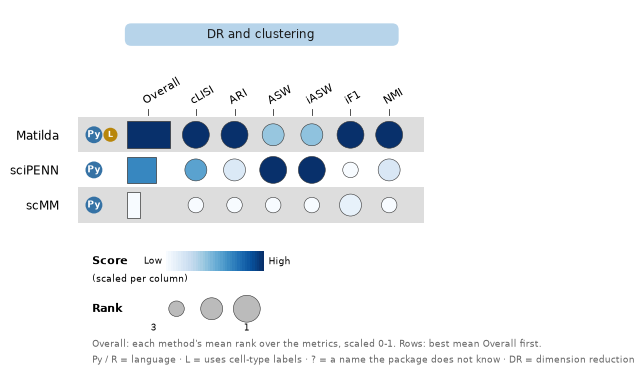

In [7]:
res.plot()

## 3. Your own data

The same calls work on a folder of your own data. Give raw counts for every modality, as in the demo data. The methods normalise the data themselves. `describe_layout` prints the files a vertical dataset needs:

In [8]:
print(mtb.describe_layout(CATEGORY))

Put the files of one dataset in one folder: <data_path>/<DATASET>/, for example ./data/MYDATA/.
The dataset name is the folder name. data_path is the folder that contains it.

vertical: Several modalities measured in the same cells (e.g. CITE-seq RNA+ADT, or 10x multiome RNA+ATAC). Cells are already matched.
  rna.h5 + adt.h5    CITE-seq (demo D11)
  rna.h5 + atac.h5   multiome
  cty.csv            cell-type labels, one per cell
atac.h5 holds peaks or gene activity. Each method needs one of them:
  need peaks:            scMVP, scMM, scMoMaT, moETM, MIRA, VIMCCA, iPOLNG, Seurat_WNN
  need gene activity:    scMDC, Matilda, UnitedNet
A method whose ATAC file holds the other representation gives a wrong embedding.
mtb.scan and mtb.run_all skip such a method unless allow_atac_mismatch=True.
mtb.run only warns, so check method_info(m)['atac'] first.

Each .h5 file holds matrix/data (features x cells, the transpose of AnnData.X),
matrix/features and matrix/barcodes. mtb.io.export_dataset wri

`labels_for` returns a dataset's label files. A vertical dataset has one, `cty`:

In [9]:
labels = mtb.labels_for(DATASET)            # {file stem: path}
print({k: Path(v).name for k, v in labels.items()})
print(*Path(next(iter(labels.values()))).read_text().splitlines()[:4], sep="\n")

{'cty': 'cty.csv'}
"x"
"mDC.Lung"
"T.CD.EM"
"B.Plasma.1"


`mtb.io.export_dataset` writes the folder from an AnnData, here a synthetic one. `scan` with `modalities=` then lists only the methods for RNA + ADT. For RNA + ATAC, each method reads either peaks or gene activity: `mtb.method_info(m)["atac"]` says which.

<details>
<summary>Details: 10x Multiome</summary>

A 10x Multiome MuData goes in with one call. Here the labels are in `mdata.obs`. For labels in `mdata["rna"].obs`, write `labels="rna:celltype"`.

```python
mtb.io.export_dataset(mdata, "data/MYMULTIOME", rna="rna", atac="atac",
                      atac_kind="peak", labels="obs:celltype",
                      category="vertical")
```

A cellranger-arc AnnData read with `gex_only=False` holds genes and peaks in one `X`. A feature filter splits them: `rna="X[feature_types=Gene Expression]"` and `atac="X[feature_types=Peaks]"`.

Keep several samples in one folder, without `batch=`. To score the batch mixing, pass the batch column to `run_all(batch=...)` or `evaluate(batch=...)`.

A call that would replace a file already in the folder raises `FileExistsError`. Pass `overwrite=True` to replace it.

</details>

In [10]:
import anndata as ad, numpy as np, scipy.sparse as sp, tempfile, os
rng = np.random.default_rng(0)
# RNA as raw counts, cells x genes
demo = ad.AnnData(X=sp.csr_matrix(rng.poisson(0.5, size=(120, 40)).astype(float)))
# ADT as raw counts, cells x proteins
demo.obsm["protein"] = rng.poisson(3.0, size=(120, 12)).astype(float)
demo.uns["protein_names"] = [f"CD{i}" for i in range(12)]
demo.obs["celltype"] = rng.choice(["T", "B", "NK"], 120)
demo.obs_names = [f"cell{i}" for i in range(120)]; demo.var_names = [f"gene{i}" for i in range(40)]

tmp = tempfile.mkdtemp()
folder = mtb.io.export_dataset(demo, os.path.join(tmp, "MYCITE"),
                               rna="X", adt="obsm:protein", labels="obs:celltype")
print(sorted(os.listdir(folder)))
sc = mtb.scan("MYCITE", CATEGORY, data_path=tmp, modalities=["rna", "adt"])
sc[["method", "modalities", "files_ok"]]

['adt.h5', 'cty.csv', 'rna.h5']
[scan] 14 of 14 methods have their input files. 0 of 14 have their environment installed. Method environments run only on Linux. On this computer you can check files, score embeddings and plot. The commands use this computer's paths, so run scan again on the Linux machine.


,method,modalities,files_ok
0,Concerto,rna+adt,True
1,MOFA2,rna+adt,True
2,Matilda,rna+adt,True
3,Multigrate,rna+adt,True
4,Seurat_WNN,rna+adt,True
5,UINMF,rna+adt,True
6,VIMCCA,rna+adt,True
7,moETM,rna+adt,True
8,scMDC,rna+adt,True
9,scMM,rna+adt,True


Next, a real dataset under a new name: a random 60% of `D11`'s cells, with at most 2,000 cells and 5,000 features per file.

<details>
<summary>Details: cell alignment</summary>

Files with the same number of cells keep the same cells in the same order. Each modality file then stays aligned with its label file. An export of your own data must keep this alignment too.

</details>

In [11]:
import os
import h5py
import numpy as np
import pandas as pd

def subsample_dataset(src_dir, dst_dir, frac=0.6, seed=0, max_cells=2000, max_features=5000):
    """Copy a dataset under a new name, keeping a random `frac` of its cells; files with the same cell count keep the same cells."""
    rng = np.random.default_rng(seed)
    os.makedirs(dst_dir, exist_ok=True)
    counts, keep = {}, {}
    for fn in sorted(os.listdir(src_dir)):
        p = os.path.join(src_dir, fn)
        if fn.endswith(".h5"):
            with h5py.File(p) as f:
                if "matrix/data" in f:
                    # matrix/data is features x cells
                    counts[fn] = f["matrix/data"].shape[1]
        elif fn.endswith(".csv"):
            counts[fn] = len(pd.read_csv(p))
    for n in set(counts.values()):
        k = min(max(50, int(n * frac)), max_cells)
        keep[n] = np.sort(rng.choice(n, size=k, replace=False))
    for fn, n in counts.items():
        sp, dp = os.path.join(src_dir, fn), os.path.join(dst_dir, fn)
        idx = keep[n]
        if fn.endswith(".csv"):
            pd.read_csv(sp).iloc[idx].to_csv(dp, index=False)
        else:
            with h5py.File(sp) as f, h5py.File(dp, "w") as g:
                grp = g.create_group("matrix")
                n_feat = f["matrix/data"].shape[0]
                fidx = np.arange(n_feat) if n_feat <= max_features else np.sort(rng.choice(n_feat, size=max_features, replace=False))
                block = f["matrix/data"][fidx, :] if n_feat > max_features else f["matrix/data"][()]
                grp.create_dataset("data", data=np.asarray(block)[:, idx])
                if "matrix/features" in f:
                    grp.create_dataset("features", data=np.asarray(f["matrix/features"])[fidx])
                if "matrix/barcodes" in f:
                    grp.create_dataset("barcodes", data=np.asarray(f["matrix/barcodes"])[idx])
    return dst_dir

`scan` checks each method variant. A variant is one set of input files that a method accepts. `files_ok` checks the folder and works on any computer. `env_ok` checks the environment. A variant is `runnable` only when both pass and its ATAC file holds the form the method reads. `reason` says what failed.

In [12]:
DATA_ROOT = "/tmp/mydata"
src = mtb.config.DEFAULT.data_path / "D11"
subsample_dataset(src, f"{DATA_ROOT}/MYDATA_vertical", frac=0.6)

sc = mtb.scan(f"MYDATA_vertical", category=CATEGORY, data_path=DATA_ROOT)
print(f"runnable: {int(sc.runnable.sum())} of {len(sc)}")
sc[["method", "modalities", "files_ok", "env_ok", "runnable", "reason"]].head(6)

[scan] 14 of 25 rows have their input files. 0 of 25 have their environment installed. Method environments run only on Linux. On this computer you can check files, score embeddings and plot. The commands use this computer's paths, so run scan again on the Linux machine.


runnable: 0 of 25


,method,modalities,files_ok,env_ok,runnable,reason
0,Concerto,rna+adt,True,False,False,"Environment scmb_concerto runs only on Linux, not on this computer."
1,MIRA,rna+atac,False,False,False,"MIRA's script imports logger.py. The public scMultiBench repository does not include it. Put a logger.py next to main_MIRA.py. mtb.method_info('MIRA')['setup_hint'] shows how. MIRA needs peak ATAC (atac.h5), which is not in the folder. Environment scmb_mira runs only on Linux, not on this computer."
2,MOFA2,rna+adt,True,False,False,"Environment MOFA2_env runs only on Linux, not on this computer."
3,Matilda,rna+adt,True,False,False,"Environment matilda runs only on Linux, not on this computer."
4,Matilda,rna+atac,False,False,False,"Matilda needs gene-activity ATAC (atac.h5), which is not in the folder. Environment matilda runs only on Linux, not on this computer."
5,Multigrate,rna+adt,True,False,False,"Environment scmb_multigrate2 runs only on Linux, not on this computer."


In [13]:
if sc[sc.method.isin(['Matilda', 'sciPENN', 'scMM'])].env_ok.any():
    mine = mtb.run_all(f"MYDATA_vertical", CATEGORY,
                       methods=['Matilda', 'sciPENN', 'scMM'],
                       out_dir=f"{DATA_ROOT}/out_vertical",
                       data_path=DATA_ROOT)
else:
    print("no method environment on this computer: the run is skipped, and outputs computed elsewhere replace it")
    # the stored results for D11s, a 60% subsample of D11
    mine = stored_sweep("D11s", ['Matilda', 'sciPENN', 'scMM'])
mine.summary

no method environment on this computer: the run is skipped, and outputs computed elsewhere replace it


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,label_order_note,caveat,reason
0,Matilda,STORED,None,None,None,<NA>,None,NaN,None,<NA>,0.940783,0.934355,0.681187,0.684397,0.966946,0.999480,not scored,NaN,
1,scMM,STORED,None,None,None,<NA>,None,NaN,None,<NA>,0.520274,0.616307,0.530001,0.528637,0.617294,0.931545,not scored,NaN,
2,sciPENN,STORED,None,None,None,<NA>,None,NaN,None,<NA>,0.610789,0.690107,0.608424,0.606649,0.659281,0.970871,not scored,NaN,


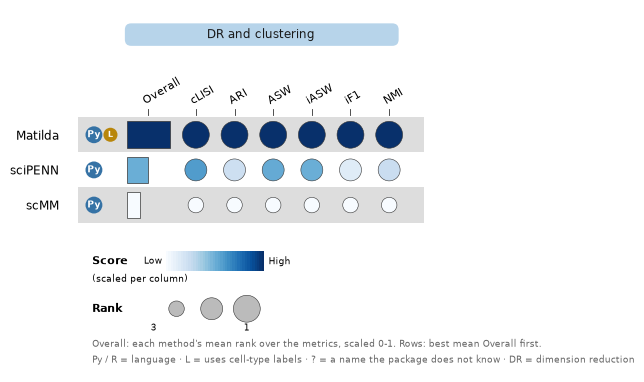

In [14]:
mine.plot()

## 4. Stored results

The package ships stored results for 13 methods on `D11`. `load_results(..., source="rerun")` reads them as a long table, and `mtb.plot.bubble` draws it. A long table has one row per method and metric. Nothing is run.

<details>
<summary>Details: sources</summary>

For `D11`, the published table holds 6 methods and the package's own runs hold 13. `load_results` defaults to `source="published"`, so every call here names its source. Where both hold a method, the values can differ.

`run_all` saves its results in `out_dir`, and `mtb.load_batch(out_dir)` reloads them later without running anything. Use one `out_dir` per dataset and category: a second `run_all` into the same folder adds its methods to the saved results, and one for another dataset raises `ValueError`.

</details>

13 methods, ['rerun']


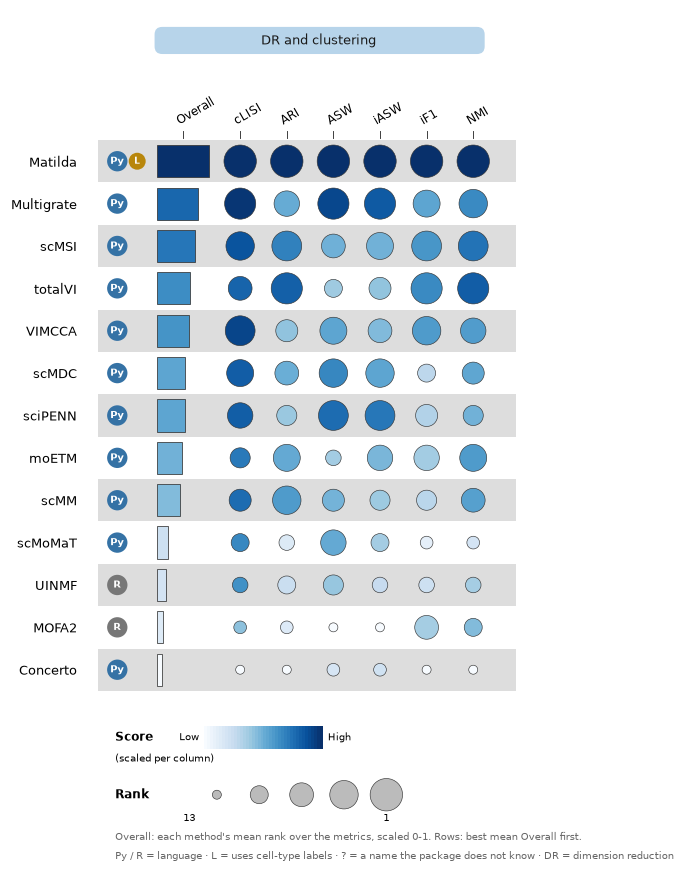

In [15]:
long = mtb.load_results(CATEGORY, dataset=DATASET, source="rerun")
print(long.method.nunique(), "methods,", long.source.unique())
fig = mtb.plot.bubble(long)
fig.set_dpi(110)
fig

A summary compares methods scored on the same datasets. `aggregate="summary"` ranks the methods over `D11` and `D11s`, a random 60% subsample of `D11`'s cells. `require_complete=True` keeps only the methods with results on both.

<details>
<summary>Details: summary bars</summary>

Each metric bar is the method's rank averaged over the datasets, then min-max scaled. `Overall` summarises the ranks of the family's metrics. Bar length and colour both show the value.

Without `require_complete=True`, a method that is missing from one dataset gets the lowest rank there, which pulls its bars down.

`D11s` is a random subsample used for the package's second run of the methods. It cannot be downloaded or rebuilt, so a summary that includes your own method uses the full datasets only.

</details>

{'D11': 13, 'D11s': 13}


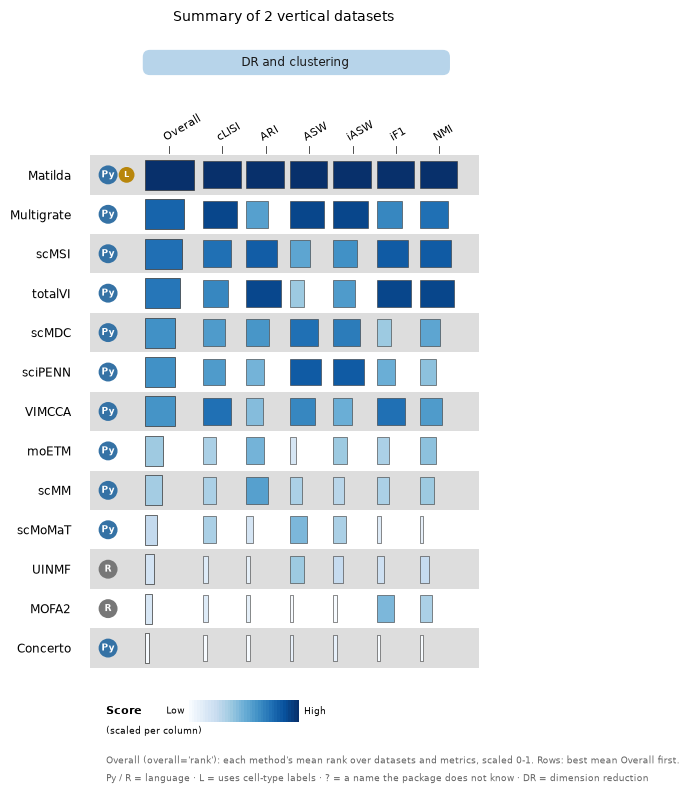

In [16]:
pair = mtb.load_results(CATEGORY, dataset=[DATASET, DATASET + "s"], source="rerun")
print(pair.groupby("dataset").method.nunique().to_dict())
mtb.plot.bubble(pair, aggregate="summary", require_complete=True,
                title=f"Summary of 2 vertical datasets")

`results_coverage` counts the methods each stored source holds for this dataset:

In [17]:
cov = mtb.results_coverage(CATEGORY)
cov[cov.dataset == DATASET].groupby("source").method.nunique()

source
published     6
rerun        13
Name: method, dtype: int64

## 5. Reference

### What runs on a dataset, and why not

`scan` on `D11` runs nothing. The first table lists the variants whose input files are in place, and `caveat` says what to check before a run. The second table says why the other variants do not fit.

<details>
<summary>Details</summary>

For a missing environment, `env_reason` gives the install command, or says that the environment runs only on Linux.

From a terminal, `multibench scan D11 --category vertical` prints the same scan. `--columns all` adds every column, including `command`: the exact command `run` would execute.

</details>

In [18]:
avail = mtb.scan(DATASET, category=CATEGORY)
print(f"runnable: {int(avail.runnable.sum())} of {len(avail)}")
avail[avail.files_ok][["method", "modalities", "env", "env_ok", "env_reason",
                       "output_kind", "needs_labels", "runtime_tier", "caveat"]]

[scan] 14 of 25 rows have their input files. 0 of 25 have their environment installed. Method environments run only on Linux. On this computer you can check files, score embeddings and plot. The commands use this computer's paths, so run scan again on the Linux machine.


runnable: 0 of 25


,method,modalities,env,env_ok,env_reason,output_kind,needs_labels,runtime_tier,caveat
0,Concerto,rna+adt,scmb_concerto,False,"Environment scmb_concerto runs only on Linux, not on this computer.",embedding,False,very_slow,
2,MOFA2,rna+adt,MOFA2_env,False,"Environment MOFA2_env runs only on Linux, not on this computer.",embedding,False,medium,
3,Matilda,rna+adt,matilda,False,"Environment matilda runs only on Linux, not on this computer.",embedding,True,fast,
5,Multigrate,rna+adt,scmb_multigrate2,False,"Environment scmb_multigrate2 runs only on Linux, not on this computer.",embedding,False,very_slow,
6,Seurat_WNN,rna+adt,scmb_seurat5,False,"Environment scmb_seurat5 runs only on Linux, not on this computer.",graph,False,medium,
8,UINMF,rna+adt,scmb_r,False,"Environment scmb_r runs only on Linux, not on this computer.",embedding,False,fast,
10,VIMCCA,rna+adt,scmb_vimcca,False,"Environment scmb_vimcca runs only on Linux, not on this computer.",embedding,False,medium,
13,moETM,rna+adt,env_moETM,False,"Environment env_moETM runs only on Linux, not on this computer. moETM needs an NVIDIA GPU, and this computer has none. See method_info(""moETM"")[""requires_gpu""].",embedding,False,medium,
15,scMDC,rna+adt,scmb_scmdc,False,"Environment scmb_scmdc runs only on Linux, not on this computer.",embedding,False,slow,
17,scMM,rna+adt,scmb_scmm2,False,"Environment scmb_scmm2 runs only on Linux, not on this computer.",embedding,False,medium,


In [19]:
not_ok = avail[~avail.files_ok][["method", "modalities", "files_reason"]]
not_ok.head(5) if len(not_ok) else "(every method's inputs resolve on this dataset)"


,method,modalities,files_reason
1,MIRA,rna+atac,"MIRA's script imports logger.py. The public scMultiBench repository does not include it. Put a logger.py next to main_MIRA.py. mtb.method_info('MIRA')['setup_hint'] shows how. FileNotFoundError: MIRA (vertical) needs atac.h5 in /tmp/mbc/multibench/data/D11. The folder holds adt.h5, cty.csv, rna.h5 and scMM_data."
4,Matilda,rna+atac,"FileNotFoundError: Matilda (vertical) needs atac.h5 in /tmp/mbc/multibench/data/D11. The folder holds adt.h5, cty.csv, rna.h5 and scMM_data."
7,Seurat_WNN,rna+atac,"FileNotFoundError: Seurat_WNN (vertical) needs atac.h5 in /tmp/mbc/multibench/data/D11. The folder holds adt.h5, cty.csv, rna.h5 and scMM_data."
9,UnitedNet,rna+atac_gas,"FileNotFoundError: UnitedNet (vertical) needs atac_gas.h5 in /tmp/mbc/multibench/data/D11. The folder holds adt.h5, cty.csv, rna.h5 and scMM_data."
11,VIMCCA,rna+atac,"FileNotFoundError: VIMCCA (vertical) needs atac.h5 in /tmp/mbc/multibench/data/D11. The folder holds adt.h5, cty.csv, rna.h5 and scMM_data."


### Tuning

The table counts the parameters each variant exposes. `mtb.params_for(method, CATEGORY, modalities)` lists them, and `run_all(..., params={"Method": {"key": value}})` sets them.

<details>
<summary>Details</summary>

Many upstream scripts set their parameters in code. Their variants accept no `params`.

From a terminal, `multibench params METHOD` prints the table, and `multibench run-all ... --param METHOD:KEY=VALUE` sets a value.

</details>

In [20]:
rows = [{"method": m, "modalities": "+".join(v["modalities"]) or "(data_dir)",
         "n_tunable": v["n_tunable"], "needs_labels": v["needs_labels"],
         "output_kind": v["output_kind"]}
        for m in sorted(mtb.list_methods(category=CATEGORY))
        for v in mtb.method_info(m)["supports"] if v["category"] == CATEGORY]
pd.DataFrame(rows).sort_values(["n_tunable", "method"], ascending=[False, True]).reset_index(drop=True)

,method,modalities,n_tunable,needs_labels,output_kind
0,scMDC,rna+adt,24,False,embedding
1,scMDC,rna+atac_gas,24,False,embedding
2,scMM,rna+adt,19,False,embedding
3,scMM,rna+atac_gas,19,False,embedding
4,Matilda,rna+adt,10,True,embedding
5,Matilda,rna+atac,10,True,embedding
6,MIRA,rna+atac,8,False,graph
7,Multigrate,rna+adt,3,False,embedding
8,UnitedNet,rna+atac_gas,1,True,embedding
9,sciPENN,rna+adt,1,False,embedding


### A method's record and citation

`method_info` returns what the package knows about a method, including its reference and repository. `mtb.cite` returns the citations for the benchmark and for the methods you pass. The cell cites Matilda. For your own work, pass every method you ran.

<details>
<summary>Details</summary>

`needs_labels` is True when any variant of the method needs cell-type labels. Each entry of `supports` gives it per variant, together with the modalities and the output kind.

`gpu` says how the method uses a GPU: `required`, `used when present`, `not used` or `unknown`.

`verbose=True` adds the long notes.

</details>

In [21]:
info = mtb.method_info("Matilda", verbose=True)
{k: info[k] for k in ("id", "env", "needs_labels", "atac", "gpu", "notes", "repo_url", "version", "reference")}

{'id': 'Matilda',
 'env': 'matilda',
 'needs_labels': True,
 'atac': 'gene_activity',
 'gpu': 'used when present',
 'notes': 'Multi-task VAE for CITE-seq / SHARE-seq / TEA-seq: one latent space serves dimension reduction and feature selection; supervised - needs labels.',
 'repo_url': 'https://github.com/PYangLab/Matilda',
 'version': '7d71480',
 'reference': {'doi': '10.1093/nar/gkad157',
  'title': 'Multi-task learning from multimodal single-cell omics with Matilda',
  'authors': 'Liu C, Huang H, Yang P',
  'journal': 'Nucleic Acids Research',
  'year': 2023}}

In [22]:
print(mtb.cite(["Matilda"]))   # fmt="bibtex" for BibTeX entries

Liu C, Ding S, Kim HJ, Long S, Xiao D, Ghazanfar S, Yang P. Multitask benchmarking of single-cell multimodal omics integration methods. Nature Methods (2025). https://doi.org/10.1038/s41592-025-02856-3
Liu C, Huang H, Yang P. Multi-task learning from multimodal single-cell omics with Matilda. Nucleic Acids Research (2023). https://doi.org/10.1093/nar/gkad157


### The metrics

There are two families, and higher is better for every metric.

| family | metrics | measures |
|---|---|---|
| clustering / bio-conservation | `ARI`, `NMI`, `ASW`, `iASW`, `iF1`, `cLISI` | whether the embedding separates the annotated cell types |
| batch correction | `ASW_batch`, `GC`, `iLISI` (+ opt-in `kBET`) | whether the batches mix within each cell type |

<details>
<summary>Details</summary>

ARI can fall slightly below 0. About 0 means a random clustering. Every other metric lies between 0 and 1. `mtb.catalog.metrics()` describes each one.

Batch metrics appear only when the dataset has more than one batch.

kBET is computed only when named, as in `metrics=["ASW_batch", "GC", "iLISI", "kBET"]`. It is much slower than the others.

</details>

### Methods from the benchmark study

The cell compares the methods the scMultiBench study benchmarked for vertical integration with the methods this package has a vertical variant for. It prints each missing method with the categories it has variants for.

In [23]:
# benchmarked for vertical on dimension reduction and clustering
paper = ['totalVI', 'sciPENN', 'Concerto', 'scMSI', 'Matilda', 'MOFA2', 'Multigrate', 'UINMF', 'scMoMaT', 'Seurat_WNN', 'scMM', 'scMDC', 'moETM', 'VIMCCA', 'iPOLNG', 'MIRA', 'UnitedNet', 'scMVP']
in_package = set(mtb.list_methods())
has_variant = sorted(m for m in in_package
                     if any(v["category"] == CATEGORY for v in mtb.method_info(m)["supports"]))
missing = [m for m in paper if m not in has_variant]
print(f"the study benchmarks {len(paper)} {CATEGORY} methods on dimension reduction and clustering")
print(f"this package has a {CATEGORY} variant for {len(has_variant)}")
for m in missing:
    if m in in_package:
        print(f"  {m}: variants for {', '.join(mtb.method_info(m)['categories'])} only")
    else:
        print(f"  {m}: not in this package")
if not missing:
    print("every benchmarked method has a variant for this category")

the study benchmarks 18 vertical methods on dimension reduction and clustering
this package has a vertical variant for 18
every benchmarked method has a variant for this category


## Troubleshooting

`scan`'s `reason` column says why a method is not runnable. `res.failures` says why a run failed or a method you named was skipped.

<details>
<summary>Details</summary>

| symptom | fix |
|---|---|
| `files_ok` False: input files not found | `reason` names the missing file |
| `env_ok` False on Linux | run the `multibench env install ...` command in `env_reason` |
| `env_ok` False on macOS or Windows | methods run only on Linux: run the same calls there |
| `env_ok` False: the method needs an NVIDIA GPU | run it on a GPU machine. On a computer without one, `mtb.scan(..., assume_gpu=True)` checks everything else |
| `FileExistsError` from `export_dataset` | the folder already holds the file: pass `overwrite=True` to replace it |
| a warning that values are not whole numbers | export raw counts, for example with `rna="layer:counts"` |
| `... matrix/data as cells x features` | the matrix is transposed: export it again with `mtb.io.export_dataset` or `mtb.io.to_canonical` |
| a method fails | `res.failures.iloc[0]["error"]` ends with the method's stderr |
| a method times out | raise `timeout=` in `run_all` |
| low `label_order_confidence` | several label files fit the cell count: check `label_order_candidates` in `res.results` |
| batch metrics use the wrong batches | `res.rescore(batch=my_vector)` scores again without running the methods |

</details>

## Next steps

- the other tutorials: diagonal, mosaic, cross
- the [interactive explorer](https://shiny.maths.usyd.edu.au/scMultiBench/): the full benchmark's rankings, no install needed
- `mtb.recommend(CATEGORY, modalities=[...])`: a ranking of methods from the stored results, to read as a hint
- `mtb.sweep(...)`: one method over a range of values of one parameter